# Multi-Agent Sales Workflow with Working Governance Metrics

This notebook implements the RAG demo pattern for proper governance metric collection.

## Key Features
- Nodes defined directly in notebook with `@evaluator` decorators
- Real-time quality metrics (context_relevance, faithfulness)
- Latency and cost tracking
- Complete workflow: Contract → Research → Matching → Action

## Setup

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import uuid
from typing import TypedDict, Optional
from typing_extensions import NotRequired

# Import agent classes (business logic)
from agents.contract_agent import ContractAgent
from agents.research_agent import research_partner
from agents.matching_agent import MatchingAgent
from agents.action_agent import ActionAgent

load_dotenv()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("[SUCCESS] Imports complete")

[SUCCESS] Imports complete


## Initialize watsonx.governance

In [2]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.config.agentic_ai_configuration import TracingConfiguration
from ibm_watsonx_gov.metrics import FaithfulnessMetric, ContextRelevanceMetric
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge


PROJECT_ID = os.getenv("WATSONX_PROJECT_ID")
REGION = os.getenv("WATSONX_REGION")

# Initialize LLM Judge
llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id=PROJECT_ID
    )
)

# Initialize Agentic Evaluator
evaluator = AgenticEvaluator(
    tracing_configuration=TracingConfiguration(
        project_id=PROJECT_ID,
        enable_metrics=True
    )
)

print("[SUCCESS] watsonx.governance initialized")

Custom exporter logging initialized. App name: Noas_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled
[SUCCESS] watsonx.governance initialized


## Initialize Agent Classes

In [3]:
APIKEY = os.getenv("WATSONX_APIKEY")

# Initialize Contract Agent
print("Initializing Contract Agent...")
contract_agent = ContractAgent(
    apikey=APIKEY,
    project_id=PROJECT_ID
)
print("✓ Contract Agent ready\n")

# Research function is imported directly
print("✓ Research function imported\n")

# Initialize Matching Agent
print("Initializing Matching Agent...")
matching_agent = MatchingAgent(
    apikey=APIKEY,
    project_id=PROJECT_ID
)
print("✓ Matching Agent ready\n")

# Initialize Action Agent
print("Initializing Action Agent...")
action_agent = ActionAgent(
    apikey=APIKEY,
    project_id=PROJECT_ID
)
print("✓ Action Agent ready\n")

print("[SUCCESS] All agents initialized")

Initializing Contract Agent...
✓ Contract Agent ready

✓ Research function imported

Initializing Matching Agent...
✓ Matching Agent ready

Initializing Action Agent...
✓ Action Agent ready

[SUCCESS] All agents initialized


## Check Contract Cache

In [4]:
import subprocess
import sys

cache_exists = os.path.exists("utils/contracts_cache.json")

if cache_exists:
    print("="*80)
    print("CONTRACT CACHE EXISTS")
    print("="*80)
    print("✓ Contracts will load instantly from cache")
    print("="*80)
else:
    print("="*80)
    print("GENERATING CONTRACT CACHE")
    print("="*80)
    print("This only needs to be done ONCE...")
    
    try:
        result = subprocess.run(
            [sys.executable, "utils/cache_contracts.py"],
            capture_output=True,
            text=True,
            timeout=300
        )
        
        if result.returncode == 0:
            print("✓ Cache generated successfully!")
        else:
            print(f"Warning: {result.stderr}")
    except Exception as e:
        print(f"Could not auto-generate: {e}")
        print("Run manually: python utils/cache_contracts.py")
    
    print("="*80)

print("\n[SUCCESS] Contract cache ready")

CONTRACT CACHE EXISTS
✓ Contracts will load instantly from cache

[SUCCESS] Contract cache ready


## Define Workflow State

In [5]:
class WorkflowState(TypedDict):
    """State for multi-agent workflow - matches RAG pattern"""
    seller_query: str
    partner_name: Optional[str]
    contract_summary: NotRequired[dict]
    partner_profile: NotRequired[dict]
    matching_data: NotRequired[dict]
    action_recommendation: NotRequired[dict]
    message_id: str

print("[SUCCESS] State defined")

[SUCCESS] State defined


## Define Workflow Nodes with Governance Decorators

Following the RAG demo pattern:
- Nodes defined in notebook with `@evaluator` decorators
- Return ONLY evaluated fields
- Context is READ from state, not returned

In [6]:
from langgraph.config import RunnableConfig

# Contract Node - Retrieval with context_relevance evaluation
contract_node_config = {
    "input_fields": ["seller_query", "partner_name"],
    "output_fields": ["contract_summary"],
    "message_id": ["message_id"]
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(**contract_node_config),
    metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def contract_node(state: WorkflowState, config: RunnableConfig) -> dict:
    """Retrieve contract information - returns ONLY context field"""
    partner_name = state.get("partner_name") or "Confluent"
    
    print(f"\n{'='*80}")
    print("EXECUTING CONTRACT AGENT")
    print(f"{'='*80}")
    print(f"Partner: {partner_name}")
    
    # Discover and load contracts
    discovered_paths = contract_agent.discover_partner_contracts(partner_name)
    result = contract_agent.run_portfolio(
        partner_name=partner_name,
        contract_paths=discovered_paths
    )
    
    print(f"Contracts processed: {len(result.get('contract_paths', []))}")
    
    # Return ONLY the context field being evaluated (RAG pattern)
    return {"contract_summary": result}

print("✓ Contract node defined with governance decorator")

✓ Contract node defined with governance decorator


In [7]:
# Research Node - Retrieval with context_relevance evaluation
research_node_config = {
    "input_fields": ["seller_query", "partner_name"],
    "output_fields": ["partner_profile"],
    "message_id": ["message_id"]
}

@evaluator.evaluate_retrieval_quality(
    configuration=AgenticAIConfiguration(**research_node_config),
    metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def research_node(state: WorkflowState, config: RunnableConfig) -> dict:
    """Research partner - returns ONLY context field"""
    partner_name = state.get("partner_name") or "Confluent"
    
    print(f"\n{'='*80}")
    print("EXECUTING RESEARCH AGENT")
    print(f"{'='*80}")
    print(f"Researching: {partner_name}")
    
    profile = research_partner(partner_name)
    
    print(f"Maturity Level: {profile.get('maturity_level', 'Unknown')}")
    print(f"Sales Velocity: {profile.get('sales_velocity', 'Unknown')}")
    
    # Return ONLY the context field being evaluated (RAG pattern)
    return {"partner_profile": profile}

print("✓ Research node defined with governance decorator")

✓ Research node defined with governance decorator


In [8]:
# Matching Node - No evaluation (intermediate processing)
def matching_node(state: WorkflowState, config: RunnableConfig) -> dict:
    """Match contracts to CRM opportunities"""
    contract_summary = state.get("contract_summary", {})
    partner_profile = state.get("partner_profile", {})
    
    print(f"\n{'='*80}")
    print("EXECUTING MATCHING AGENT")
    print(f"{'='*80}")
    
    # Extract CRM opportunities from partner profile
    internal_data = partner_profile.get("internal_data", {})
    sales_history = internal_data.get("sales_history", {})
    crm_opportunities = sales_history.get("opportunities", [])
    
    result = matching_agent.run(
        contract_portfolio=contract_summary,
        crm_opportunities=crm_opportunities
    )
    
    matched_count = len(result.get("matched_contracts", []))
    unmatched_count = len(result.get("unmatched_contracts", []))
    print(f"Matched: {matched_count}, Unmatched: {unmatched_count}")
    
    return {"matching_data": result}

print("✓ Matching node defined")

✓ Matching node defined


In [9]:
# Action Node - Generation with faithfulness evaluation
action_node_config = {
    "input_fields": ["seller_query", "partner_name"],
    "context_fields": ["contract_summary", "partner_profile"],
    "output_fields": ["action_recommendation"],
    "message_id": ["message_id"]
}

@evaluator.evaluate_faithfulness(
    configuration=AgenticAIConfiguration(**action_node_config),
    metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
    compute_real_time=True
)
def action_node(state: WorkflowState, config: RunnableConfig) -> dict:
    """Generate action plan - returns ONLY output field, READS context from state"""
    print(f"\n{'='*80}")
    print("EXECUTING ACTION AGENT")
    print(f"{'='*80}")
    
    # READ context from state (RAG pattern - don't return context)
    contract_summary = state.get("contract_summary", {})
    partner_profile = state.get("partner_profile", {})
    matching_data = state.get("matching_data", {})
    seller_query = state.get("seller_query", "")
    
    result = action_agent.run(
        contract_summary,
        partner_profile,
        seller_query,
        matching_data
    )
    
    print(f"Risk Level: {result.get('risk_level', 'Unknown')}")
    print(f"Risk Score: {result.get('risk_score', 0)}/100")
    
    # Return ONLY the output field being evaluated (RAG pattern)
    return {"action_recommendation": result}

print("✓ Action node defined with governance decorator")
print("\n[SUCCESS] All nodes defined with governance decorators")

✓ Action node defined with governance decorator

[SUCCESS] All nodes defined with governance decorators


## Build LangGraph Workflow

In [10]:
from langgraph.graph import START, END, StateGraph

# Build the graph
print("Building workflow graph...")
builder = StateGraph(WorkflowState)

# Add nodes
builder.add_node("contract", contract_node)
builder.add_node("research", research_node)
builder.add_node("matching", matching_node)
builder.add_node("action", action_node)

# Add edges
builder.add_edge(START, "contract")
builder.add_edge("contract", "research")
builder.add_edge("research", "matching")
builder.add_edge("matching", "action")
builder.add_edge("action", END)

# Compile
workflow = builder.compile()

print("[SUCCESS] Workflow graph built with decorated nodes")

Building workflow graph...
[SUCCESS] Workflow graph built with decorated nodes


## Visualize Workflow

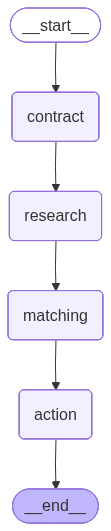

In [11]:
from IPython.display import Image, display

try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("Graph structure: START → contract → research → matching → action → END")

## Run Workflow with Governance

In [12]:
# Test query
test_query = "I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps"

# Initial state
initial_state = {
    "seller_query": test_query,
    "partner_name": "Confluent",
    "message_id": str(uuid.uuid4())
}

print(f"\n{'='*80}")
print("RUNNING WORKFLOW WITH GOVERNANCE")
print(f"{'='*80}")
print(f"Query: {test_query[:100]}...")
print(f"Message ID: {initial_state['message_id']}")
print(f"{'='*80}\n")

# Start governance tracking
evaluator.start_run()

# Run workflow
result = workflow.invoke(initial_state)

# End governance tracking
evaluator.end_run()

print(f"\n{'='*80}")
print("[SUCCESS] Workflow execution completed")
print(f"{'='*80}")


RUNNING WORKFLOW WITH GOVERNANCE
Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what co...
Message ID: 069a0fda-149a-46f9-a88d-e9174d7284d4


EXECUTING CONTRACT AGENT
Partner: Confluent
✓ Using cached data for: Confluent_IBM-1.30.2024.docx
✓ Using cached metadata for: Confluent_IBM-1.30.2024.docx
✓ Using cached structured data for: Confluent_IBM-1.30.2024.docx
✓ Using cached data for: Confluent_IBM-1.30.2025.docx
✓ Using cached metadata for: Confluent_IBM-1.30.2025.docx
✓ Using cached structured data for: Confluent_IBM-1.30.2025.docx
✓ Using cached data for: Confluent_IBM-5.30.2023.docx
✓ Using cached metadata for: Confluent_IBM-5.30.2023.docx
✓ Using cached structured data for: Confluent_IBM-5.30.2023.docx
✓ Using cached data for: Confluent_IBM-7.31.2024.docx
✓ Using cached metadata for: Confluent_IBM-7.31.2024.docx
✓ Using cached structured data for: Confluent_IBM-7.31.2024.docx
Contracts processed: 4
[Warning] No region provided 

## Display Results

In [13]:
# Display action recommendation
action_rec = result.get("action_recommendation", {})

print(f"\n{'='*80}")
print("ACTION RECOMMENDATION")
print(f"{'='*80}\n")

# Risk Assessment
risk = action_rec.get("risk_assessment", {})
print(f"Risk Level: {risk.get('risk_level', 'Unknown')}")
print(f"Risk Score: {risk.get('risk_score', 0)}/100\n")

# Recommended Action
recommended = action_rec.get("recommended_action", {})
if recommended:
    print("Recommended Next Step:")
    print(recommended.get("raw_recommendation", "No recommendation"))
    print()

# Draft Email
draft_email = action_rec.get("draft_email", "")
if draft_email:
    print(f"\n{'='*80}")
    print("DRAFT EMAIL")
    print(f"{'='*80}\n")
    print(draft_email[:500] + "..." if len(draft_email) > 500 else draft_email)

print(f"\n{'='*80}")


ACTION RECOMMENDATION

Risk Level: High
Risk Score: 80/100

Recommended Next Step:
DETAILED CONTRACT ANALYSIS WITH REASONING

PRIORITY 1: CRITICAL URGENCY - IMMEDIATE ACTION REQUIRED

CONTRACT: Confluent_IBM-1.30.2025.docx
- Product(s): watsonx
- Value: $250,003.20
- Previous Signers: Unknown
- Status: EXPIRED (87 days ago)
- End Date: 2026-01-31

CRM LINKAGE:
- CRM Status: CONTRACT SIGNED
- Opportunity: "Confluent watsonx ESA"
- Owner: Anand Das
- Stage: Won
- Amount:  $250,000.00 
- Close Date: 1/31/25
- Next Steps: "CFO signed 1 year renewals"

WHY DID THIS CONTRACT EXPIRE?
- Primary Reason: Natural expiration after successful engagement
  Deal was won but contract may have expired naturally

EXPANSION OPPORTUNITY ANALYSIS:
- Can Expand: NO
- Recommendation: Focus on renewal at current scope

URGENCY ANALYSIS:
- Contract expired 87 days ago
- $250,003.20 renewal opportunity at risk
- Renewal discussions in progress
- Competitor could enter during gap period

KEY PEOPLE TO CONTACT:


## Display Governance Metrics

In [14]:
# Get metrics from evaluator
eval_result = evaluator.get_result()

print(f"\n{'='*80}")
print("METRICS SUMMARY")
print(f"{'='*80}\n")

if eval_result is None:
    print("[WARNING] No evaluation results found")
    print("\nThis indicates the decorators may not be capturing metrics properly.")
    print("\nDebugging information:")
    print(f"- Evaluator type: {type(evaluator)}")
    print(f"- LLM Judge configured: {llm_judge is not None}")
    print(f"- Workflow executed: {result is not None}")
    print("\nPossible issues:")
    print("1. Decorator configuration mismatch")
    print("2. LLM judge not properly initialized")
    print("3. Metrics not being computed in real-time")
    print(f"\n{'='*80}")
else:
    metrics_df = eval_result.to_df()
    
    if metrics_df is not None and not metrics_df.empty:
        print("Full Metrics DataFrame:")
        print(f"Columns: {list(metrics_df.columns)}")
        print(f"Shape: {metrics_df.shape}")
        print()
        display(metrics_df)
        print()
        
        # Extract and display metrics by category
        print(f"{'='*80}")
        print("DETAILED METRICS BREAKDOWN")
        print(f"{'='*80}\n")
        
        cols = list(metrics_df.columns)
        
        # Get first row (assuming single execution)
        if len(metrics_df) > 0:
            row = metrics_df.iloc[0]
            
            # Latency Metrics
            print("Latency (seconds):")
            latency_cols = [c for c in cols if c.endswith('.latency')]
            if latency_cols:
                for col in sorted(latency_cols):
                    value = row[col]
                    if pd.notna(value):
                        print(f"  {col}: {value:.4f}s")
            else:
                print("  No latency metrics found")
            print()
            
            # Quality Metrics
            print("Quality Metrics:")
            quality_cols = [c for c in cols if any(metric in c.lower() for metric in 
                           ['context_relevance', 'faithfulness', 'retrieval_precision', 
                            'answer_relevance', 'hallucination'])]
            if quality_cols:
                for col in sorted(quality_cols):
                    value = row[col]
                    if pd.notna(value):
                        print(f"  {col}: {value:.4f}")
            else:
                print("  No quality metrics found")
            print()
            
            # Cost Metrics
            print("Cost:")
            if 'message.cost' in cols and pd.notna(row['message.cost']):
                print(f"  Total: ${row['message.cost']:.4f}")
            if 'message.input_token_count' in cols and pd.notna(row['message.input_token_count']):
                print(f"  Input tokens: {int(row['message.input_token_count'])}")
            if 'message.output_token_count' in cols and pd.notna(row['message.output_token_count']):
                print(f"  Output tokens: {int(row['message.output_token_count'])}")
            if 'message.duration' in cols and pd.notna(row['message.duration']):
                print(f"  Total duration: {row['message.duration']:.4f}s")
            print()
            
            # Other Metrics
            other_cols = [c for c in cols if c not in latency_cols + quality_cols + 
                         ['message.cost', 'message.input_token_count', 'message.output_token_count', 
                          'message.duration', 'message_id']]
            if other_cols:
                print("Other Metrics:")
                for col in sorted(other_cols):
                    value = row[col]
                    if pd.notna(value):
                        print(f"  {col}: {value}")
                print()
        
        print(f"{'='*80}")
        print("[SUCCESS] Workflow completed - metrics retrieved")
        print(f"{'='*80}")
    else:
        print("[WARNING] Metrics DataFrame is empty")
        print(f"{'='*80}")


METRICS SUMMARY

Full Metrics DataFrame:
Columns: ['message_id', 'action.latency', 'contract.latency', 'matching.latency', 'message.cost', 'message.duration', 'message.input_token_count', 'message.output_token_count', 'research.latency']
Shape: (1, 9)



,message_id,action.latency,contract.latency,matching.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,research.latency
0,eb1167b367a9c3787c65c1e582e2e662,4.7131,23.2073,64.4386,0.0093,109.9345,10423.0,2606.0,17.5045



DETAILED METRICS BREAKDOWN

Latency (seconds):
  action.latency: 4.7131s
  contract.latency: 23.2073s
  matching.latency: 64.4386s
  research.latency: 17.5045s

Quality Metrics:
  No quality metrics found

Cost:
  Total: $0.0093
  Input tokens: 10423
  Output tokens: 2606
  Total duration: 109.9345s

[SUCCESS] Workflow completed - metrics retrieved


## Summary

This notebook implements the RAG demo pattern for proper governance metric collection:

1. **Nodes defined in notebook** with `@evaluator.decorator` syntax
2. **Return only evaluated fields** (contract_summary, partner_profile, action_recommendation)
3. **Context read from state** in generation nodes (not returned)
4. **RunnableConfig parameter** in all node signatures
5. **evaluator.start_run() / end_run()** to track metrics

Expected metrics:
- `contract.context_relevance`: Quality of contract retrieval
- `research.context_relevance`: Quality of partner research
- `action.faithfulness`: How well action follows context
- Latency for each node
- Total cost